### Модуль создания, обучения и оценки модели распознавания степени усталости

In [60]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import numpy as np
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import seaborn as sns


np.random.seed(13) 
tf.random.set_seed(13)

In [81]:
class MacroF1(tf.keras.metrics.Metric):
    """
    Класс метрики Macro F1 для многоклассовой классификации.

    Атрибуты:
        num_classes (int): количество классов.
        true_positives (tf.Variable): число истинно положительных по каждому классу.
        false_positives (tf.Variable): число ложно положительных по каждому классу.
        false_negatives (tf.Variable): число ложно отрицательных по каждому классу.

    Использование:
        Экземпляр данной метрики можно передавать в качестве метрики при компиляции модели Keras.
    """

    def __init__(self, num_classes=3, name="macro_f1", **kwargs):
        """
        Инициализация метрики.

        Аргументы:
            num_classes (int): количество классов.
            name (str): имя метрики.
            **kwargs: дополнительные параметры для базового класса.
        """
        super().__init__(name=name, **kwargs)
        self.num_classes = num_classes
        self.true_positives = self.add_weight(name="tp", shape=(num_classes,), initializer="zeros", dtype=tf.float32)
        self.false_positives = self.add_weight(name="fp", shape=(num_classes,), initializer="zeros", dtype=tf.float32)
        self.false_negatives = self.add_weight(name="fn", shape=(num_classes,), initializer="zeros", dtype=tf.float32)

    def update_state(self, y_true, y_pred, sample_weight=None):
        """
        Обновляет значения TP, FP, FN после очередного батча.

        Аргументы:
            y_true (tf.Tensor): истинные значения (one-hot или индексы).
            y_pred (tf.Tensor): предсказанные значения (one-hot или вероятности).
            sample_weight (tf.Tensor, optional): веса выборки (не используется).
        """
        y_true = tf.cast(tf.reshape(y_true, [-1, self.num_classes]), tf.float32)
        y_pred = tf.cast(tf.reshape(y_pred, [-1, self.num_classes]), tf.float32)
        y_true_labels = tf.argmax(y_true, axis=-1)
        y_pred_labels = tf.argmax(y_pred, axis=-1)
        
        for i in range(self.num_classes):
            y_true_i = tf.equal(y_true_labels, i)
            y_pred_i = tf.equal(y_pred_labels, i)
            tp = tf.reduce_sum(tf.cast(tf.logical_and(y_true_i, y_pred_i), self.dtype))
            fp = tf.reduce_sum(tf.cast(tf.logical_and(tf.logical_not(y_true_i), y_pred_i), self.dtype))
            fn = tf.reduce_sum(tf.cast(tf.logical_and(y_true_i, tf.logical_not(y_pred_i)), self.dtype))
            
            updates_tp = tf.tensor_scatter_nd_add(self.true_positives, [[i]], [tp])
            updates_fp = tf.tensor_scatter_nd_add(self.false_positives, [[i]], [fp])
            updates_fn = tf.tensor_scatter_nd_add(self.false_negatives, [[i]], [fn])

            self.true_positives.assign(updates_tp)
            self.false_positives.assign(updates_fp)
            self.false_negatives.assign(updates_fn)

    def result(self):
        """
        Вычисляет итоговое значение Macro F1 по накопленным показателям.

        Возвращает:
            tf.Tensor: macro F1-score (среднее значение F1 по классам).
        """
        precision = tf.math.divide_no_nan(self.true_positives, self.true_positives + self.false_positives)
        recall = tf.math.divide_no_nan(self.true_positives, self.true_positives + self.false_negatives)
        f1 = tf.math.divide_no_nan(2 * precision * recall, precision + recall)
        macro_f1 = tf.reduce_mean(f1)
        return macro_f1

    def reset_states(self):
        """
        Сброс накопленных счетчиков TP, FP, FN перед новой эпохой.
        """
        self.true_positives.assign(tf.zeros_like(self.true_positives))
        self.false_positives.assign(tf.zeros_like(self.false_positives))
        self.false_negatives.assign(tf.zeros_like(self.false_negatives))


# ============================================================================
# АРХИТЕКТУРА CNN-BiGRU
# ============================================================================

def create_cnn_bigru_model(
    temporal_shape=(101, 18),
    n_classes=3,
    use_handcrafted=True,
    conv_filters=(96, 192, 384),
    gru_units=160,
    dropout_conv=0.16,
    dropout_gru=0.36,
    dropout_fc=0.36,
    l2_reg=5e-5
):
    """
    Создает архитектуру модели CNN-BiGRU для мультиклассовой классификации.

    Аргументы:
        temporal_shape (tuple): размерность входного тензора временных признаков (time, features)
        n_classes (int): количество классов для классификации.
        use_handcrafted (bool): использовать ли ручные признаки.
        conv_filters (tuple): кортеж с количеством фильтров для каждого сверточного слоя.
        gru_units (int): количество нейронов в GRU-слое.
        dropout_conv (float): dropout после сверточных слоев.
        dropout_gru (float): dropout в GRU-слое.
        dropout_fc (float): dropout в полносвязных слоях.
        l2_reg (float): коэффициент регуляризации L2.

    Возвращает:
        tf.keras.Model: скомпилированная модель Keras.
    """
    regularizer = tf.keras.regularizers.l2(l2_reg)

    temporal_input = layers.Input(shape=temporal_shape, name='temporal_input')
    x = temporal_input

    x = layers.LayerNormalization(name='input_ln')(x)
    x = layers.Dropout(0.07, name='input_dropout')(x)

    for i, filters in enumerate(conv_filters):
        x = layers.Conv1D(
            filters, 
            kernel_size=3 if i > 0 else 7, 
            padding='same', 
            kernel_regularizer=regularizer, 
            name=f'conv1d_{i}'
        )(x)
        x = layers.BatchNormalization(name=f'bn_{i}')(x)
        if i == len(conv_filters) - 1:
            x = layers.Activation('relu', name=f'relu_{i}')(x)
        else:
            x = layers.Activation('gelu', name=f'gelu_{i}')(x)
        x = layers.MaxPooling1D(2, name=f'maxpool_{i}')(x)
        x = layers.Dropout(dropout_conv, name=f'dropout_conv_{i}')(x)

    x = layers.Bidirectional(
        layers.GRU(
            gru_units, 
            return_sequences=False,
            dropout=dropout_gru,
            recurrent_dropout=0, 
            kernel_regularizer=regularizer,
            name='gru'
        ),
        name='bidirectional_gru'
    )(x)

    if use_handcrafted:
        handcrafted_input = layers.Input(shape=(2,), name='handcrafted_input')
        hand_bn = layers.BatchNormalization(name='hand_bn')(handcrafted_input)
        combined = layers.Concatenate(name='concat')([x, hand_bn])
    else:
        combined = x

    z = layers.Dense(300, activation='gelu', kernel_regularizer=regularizer, name='dense_1')(combined)
    z = layers.BatchNormalization(name='dense1_bn')(z)
    z = layers.Dropout(dropout_fc, name='dropout_fc')(z)
    z = layers.Dense(160, activation='gelu', kernel_regularizer=regularizer, name='dense_2')(z)
    z = layers.BatchNormalization(name='dense2_bn')(z)
    z = layers.Dropout(dropout_fc, name='dropout_fc2')(z)
    output = layers.Dense(n_classes, activation='softmax', name='output')(z)

    if use_handcrafted:
        model = models.Model(
            inputs=[temporal_input, handcrafted_input],
            outputs=output,
            name='CNN_BiGRU_Fatigue'
        )
    else:
        model = models.Model(
            inputs=temporal_input,
            outputs=output,
            name='CNN_BiGRU_Fatigue'
        )

    return model


# ============================================================================
# ЗАГРУЗКА И РАЗДЕЛЕНИЕ ДАННЫХ
# ============================================================================

def load_fatigue_dataset(npz_path: str):
    """
    Загружает датасет утомления из .npz-файла и формирует нужные массивы.

    Аргументы:
        npz_path (str): путь к .npz-файлу с данными.

    Возвращает:
        tuple: кортеж (temporals, handcrafted, labels), где:
            temporals (np.ndarray): временные признаки формы (n_samples, time_steps, features)
            handcrafted (np.ndarray): ручные признаки, например джиттер и шиммер (n_samples, 2)
            labels (np.ndarray): целевые значения классов (n_samples,)
    """
    data = np.load(npz_path, allow_pickle=True)
    temporals = data['temporals']
    jitters = data['jitters']
    shimmers = data['shimmers']
    labels = data['labels']

    temporals = temporals.astype(np.float32)
    jitters = jitters.astype(np.float32)
    shimmers = shimmers.astype(np.float32)
    labels = labels.astype(np.int32)

    handcrafted = np.stack([jitters, shimmers], axis=1)

    print(f"Загружено {len(temporals)} образцов")
    print(f"Временные признаки: {temporals.shape}")
    print(f"Ручные признаки: {handcrafted.shape}")
    print(f"Метки: {labels.shape}")
    print(f"Распределение классов: {np.bincount(labels)}")

    return temporals, handcrafted, labels


def split_fatigue_dataset(temporals, handcrafted, labels,
                          train_ratio=0.7, val_ratio=0.15, test_ratio=0.15,
                          random_state=28):
    """
    Делит датасет на обучающую, валидационную и тестовую выборки с сохранением пропорции классов.

    Аргументы:
        temporals (np.ndarray): временные признаки.
        handcrafted (np.ndarray): ручные признаки.
        labels (np.ndarray): метки классов.
        train_ratio (float): доля обучающей выборки.
        val_ratio (float): доля валидационной выборки.
        test_ratio (float): доля тестовой выборки.
        random_state (int): seed для случайного разбиения.

    Возвращает:
        dict: словарь с ключами 'X_train', 'X_val', 'X_test', 'H_train', 'H_val', 'H_test', 
              'y_train', 'y_val', 'y_test', хранящий соответствующие массивы.
    """
    assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-6

    X_train, X_temp, H_train, H_temp, y_train, y_temp = train_test_split(
        temporals, handcrafted, labels,
        test_size=(1 - train_ratio),
        stratify=labels,
        random_state=random_state
    )

    val_fraction = test_ratio / (val_ratio + test_ratio)

    X_val, X_test, H_val, H_test, y_val, y_test = train_test_split(
        X_temp, H_temp, y_temp,
        test_size=val_fraction,
        stratify=y_temp,
        random_state=random_state
    )

    print(f"Разделение данных:")
    print(f"  Train: {len(X_train)} ({len(X_train)/len(temporals)*100:.1f}%)")
    print(f"  Val:   {len(X_val)} ({len(X_val)/len(temporals)*100:.1f}%)")
    print(f"  Test:  {len(X_test)} ({len(X_test)/len(temporals)*100:.1f}%)")
    print(f"Распределение классов в train: {np.bincount(y_train)}")

    return {
        'X_train': X_train,
        'X_val': X_val,
        'X_test': X_test,
        'H_train': H_train,
        'H_val': H_val,
        'H_test': H_test,
        'y_train': y_train,
        'y_val': y_val,
        'y_test': y_test
    }


# ============================================================================
# ОБУЧЕНИЕ МОДЕЛИ
# ============================================================================

def train_fatigue_model(model, train_data, val_data, epochs=160, batch_size=20):
    """
    Обучает модель на обучающей выборке и валидирует на валидационной выборке.

    Аргументы:
        model (tf.keras.Model): созданная модель.
        train_data (tuple): кортеж (X_train, H_train, y_train) либо (X_train, y_train), в зависимости от архитектуры.
        val_data (tuple): кортеж (X_val, H_val, y_val) либо (X_val, y_val).
        epochs (int): максимальное число эпох обучения.
        batch_size (int): размер батча.

    Возвращает:
        History: объект истории обучения Keras (tf.keras.callbacks.History).
    """
    X_train, H_train, y_train = train_data
    X_val, H_val, y_val = val_data

    n_classes = len(np.unique(np.concatenate([y_train, y_val])))
    y_train_cat = tf.keras.utils.to_categorical(y_train, num_classes=n_classes)
    y_val_cat = tf.keras.utils.to_categorical(y_val, num_classes=n_classes)

    class_weight_dict = {0: 0.70, 1: 1.70, 2: 2.30}
    print(f"Веса классов: {class_weight_dict}")

    opt = tf.keras.optimizers.AdamW(learning_rate=1e-4, weight_decay=2e-4)

    macro_f1 = MacroF1(num_classes=n_classes)
    model.compile(
        optimizer=opt,
        loss='categorical_crossentropy',
        metrics=['accuracy', 'precision', 'recall', 'auc', macro_f1]
    )

    early_stopping = callbacks.EarlyStopping(
        monitor='val_macro_f1',
        patience=12,
        restore_best_weights=True,
        mode='max',
        verbose=1
    )

    reduce_lr = callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.45,
        patience=10,
        min_lr=1e-6,
        verbose=1
    )

    checkpoint = callbacks.ModelCheckpoint(
        'best_fatigue_model_18_b2.keras',
        monitor='val_macro_f1',
        save_best_only=True,
        mode='max',
        verbose=1
    )

    callbacks_list = [early_stopping, reduce_lr, checkpoint]

    history = model.fit(
        [X_train, H_train] if len(model.inputs) == 2 else X_train,
        y_train_cat,
        validation_data=([X_val, H_val] if len(model.inputs) == 2 else X_val, y_val_cat),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks_list,
        class_weight=class_weight_dict,
        verbose=2,
        shuffle=True
    )

    return history

# ============================================================================
# ОЦЕНКА МОДЕЛИ
# ============================================================================

def evaluate_fatigue_model(model, test_data):
    """
    Оценивает модель на тестовых данных, выводит отчеты и возвращает предсказания.

    Аргументы:
        model (tf.keras.Model): обученная модель.
        test_data (tuple): кортеж (X_test, H_test, y_test) либо (X_test, y_test), в зависимости от входов модели.

    Возвращает:
        tuple: кортеж (y_pred, y_pred_proba), где
            y_pred (np.ndarray): предсказанные классы (индексы).
            y_pred_proba (np.ndarray): вероятности классов (n_samples, n_classes).
    """
    X_test, H_test, y_test = test_data
    n_classes = len(np.unique(y_test))
    y_test_cat = tf.keras.utils.to_categorical(y_test, num_classes=n_classes)

    results = model.evaluate(
        [X_test, H_test] if len(model.inputs) == 2 else X_test,
        y_test_cat,
        verbose=0
    )
    metric_names = model.metrics_names
    scores = dict(zip(metric_names, results))

    y_pred_proba = model.predict(
        [X_test, H_test] if len(model.inputs) == 2 else X_test,
        verbose=0
    )
    y_pred = np.argmax(y_pred_proba, axis=1)

    print(f"\n{'='*60}")
    print("РЕЗУЛЬТАТЫ НА ТЕСТОВОЙ ВЫБОРКЕ")
    print(f"{'='*60}")
    print(" | ".join(f"{k}: {scores[k]:.4f}" for k in metric_names if k in scores))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, 
                                 target_names=['Нет усталости', 'Слабая усталость', 'Сильная усталость']))
    macro_f1 = f1_score(y_test, y_pred, average='macro')
    print(f"\nMacro F1-score (sklearn): {macro_f1:.4f}")
    print("\nConfusion matrix:")
    print(confusion_matrix(y_test, y_pred))

    return y_pred, y_pred_proba

#### Загрузка, разделение на выборки и нормализация данных 

In [82]:
FEATURES_CNT = 18  # количество выбранных признаков

npz_path = f"D:/python_for_data/vkr/fatigue_selected_{FEATURES_CNT}_features.npz"
temporals, handcrafted, labels = load_fatigue_dataset(npz_path)
split = split_fatigue_dataset(temporals, handcrafted, labels, random_state=119) 
scaler_h = StandardScaler()
scaler_t = StandardScaler()

perm_train = np.random.RandomState(42).permutation(len(split['X_train']))
X_train = split['X_train'][perm_train]
H_train = split['H_train'][perm_train]
y_train = split['y_train'][perm_train]

X_val = split['X_val']
H_val = split['H_val']
y_val = split['y_val']
X_test = split['X_test']
H_test = split['H_test']
y_test = split['y_test']

H_train_norm = scaler_h.fit_transform(H_train)
H_val_norm = scaler_h.transform(H_val)
H_test_norm = scaler_h.transform(H_test)

shape_t = X_train.shape
X_train_2d = X_train.reshape([-1, shape_t[-1]])
X_train_norm = scaler_t.fit_transform(X_train_2d).reshape(shape_t)
X_val_norm = scaler_t.transform(X_val.reshape([-1, shape_t[-1]])).reshape(X_val.shape)
X_test_norm = scaler_t.transform(X_test.reshape([-1, shape_t[-1]])).reshape(X_test.shape)

Загружено 3364 образцов
Временные признаки: (3364, 101, 18)
Ручные признаки: (3364, 2)
Метки: (3364,)
Распределение классов: [1486 1238  640]
Разделение данных:
  Train: 2354 (70.0%)
  Val:   505 (15.0%)
  Test:  505 (15.0%)
Распределение классов в train: [1040  866  448]


#### Создание архитектуры модели

In [83]:
model = create_cnn_bigru_model(
    temporal_shape=(101, FEATURES_CNT),
    n_classes=3,
    use_handcrafted=True,
    conv_filters=(96, 192, 384),
    gru_units=160,
    dropout_conv=0.16,
    dropout_gru=0.36, 
    dropout_fc=0.36,
    l2_reg=5e-5
)

model.summary()

Model: "CNN_BiGRU_Fatigue"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ temporal_input      │ (None, 101, 18)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_ln            │ (None, 101, 18)   │         36 │ temporal_input[0… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_dropout       │ (None, 101, 18)   │          0 │ input_ln[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_0 (Conv1D)   │ (None, 101, 96)   │     12,192 │ input_dropout[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_0                │ (None, 101, 96)   │        384 │ conv1d_0[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gelu_0 (Activation) │ (None, 101, 96)   │          0 │ bn_0[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ maxpool_0           │ (None, 50, 96)    │          0 │ gelu_0[0][0]      │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_conv_0      │ (None, 50, 96)    │          0 │ maxpool_0[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 50, 192)   │     55,488 │ dropout_conv_0[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_1                │ (None, 50, 192)   │        768 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gelu_1 (Activation) │ (None, 50, 192)   │          0 │ bn_1[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ maxpool_1           │ (None, 25, 192)   │          0 │ gelu_1[0][0]      │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_conv_1      │ (None, 25, 192)   │          0 │ maxpool_1[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 25, 384)   │    221,568 │ dropout_conv_1[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_2                │ (None, 25, 384)   │      1,536 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ relu_2 (Activation) │ (None, 25, 384)   │          0 │ bn_2[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ maxpool_2           │ (None, 12, 384)   │          0 │ relu_2[0][0]      │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_conv_2      │ (None, 12, 384)   │          0 │ maxpool_2[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ handcrafted_input   │ (None, 2)         │          0 │ -               

 Total params: 963,523 (3.68 MB)

 Trainable params: 961,255 (3.67 MB)

 Non-trainable params: 2,268 (8.86 KB)

#### Обучение модели

In [84]:
train_data = (X_train_norm, H_train_norm, y_train)
val_data = (X_val_norm, H_val_norm, y_val)

history = train_fatigue_model(model, train_data, val_data, epochs=100, batch_size=20)

Веса классов: {0: 0.7, 1: 1.7, 2: 2.3}
Epoch 1/100


c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\models\functional.py:225: UserWarning: The structure of `inputs` doesn't match the expected structure: ['temporal_input', 'handcrafted_input']. Received: the structure of inputs=('*', '*')
  warnings.warn(



Epoch 1: val_macro_f1 improved from -inf to 0.43411, saving model to best_fatigue_model_18_b2.keras
118/118 - 20s - 173ms/step - accuracy: 0.3955 - auc: 0.5847 - loss: 2.2466 - macro_f1: 0.3851 - precision: 0.3980 - recall: 0.3522 - val_accuracy: 0.5366 - val_auc: 0.7519 - val_loss: 1.0410 - val_macro_f1: 0.4341 - val_precision: 0.7433 - val_recall: 0.2752 - learning_rate: 1.0000e-04
Epoch 2/100

Epoch 2: val_macro_f1 improved from 0.43411 to 0.53670, saving model to best_fatigue_model_18_b2.keras
118/118 - 6s - 52ms/step - accuracy: 0.4847 - auc: 0.6697 - loss: 1.9483 - macro_f1: 0.4768 - precision: 0.4967 - recall: 0.4516 - val_accuracy: 0.5822 - val_auc: 0.7938 - val_loss: 0.9319 - val_macro_f1: 0.5367 - val_precision: 0.6615 - val_recall: 0.4218 - learning_rate: 1.0000e-04
Epoch 3/100

Epoch 3: val_macro_f1 improved from 0.53670 to 0.57335, saving model to best_fatigue_model_18_b2.keras
118/118 - 6s - 55ms/step - accuracy: 0.5153 - auc: 0.7018 - loss: 1.7278 - macro_f1: 0.5083 - p

#### Оценка модели


In [85]:
test_data = (X_test_norm, H_test_norm, y_test)

evaluate_fatigue_model(model, test_data)


РЕЗУЛЬТАТЫ НА ТЕСТОВОЙ ВЫБОРКЕ
loss: 0.4139 | compile_metrics: 0.8851

Classification Report:
                   precision    recall  f1-score   support

    Нет усталости       0.96      0.94      0.95       223
 Слабая усталость       0.89      0.80      0.84       186
Сильная усталость       0.73      0.92      0.81        96

         accuracy                           0.89       505
        macro avg       0.86      0.89      0.87       505
     weighted avg       0.89      0.89      0.89       505


Macro F1-score (sklearn): 0.8705

Confusion matrix:
[[210  10   3]
 [  8 149  29]
 [  0   8  88]]


(array([0, 2, 1, 1, 0, 2, 1, 0, 1, 0, 1, 0, 0, 2, 2, 0, 1, 0, 0, 0, 0, 2,
        2, 2, 1, 0, 0, 1, 1, 1, 2, 0, 0, 1, 2, 1, 2, 0, 0, 2, 0, 1, 0, 0,
        0, 0, 0, 2, 2, 1, 1, 1, 1, 2, 2, 0, 1, 0, 1, 2, 2, 1, 1, 1, 0, 1,
        0, 0, 1, 1, 0, 2, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0,
        0, 0, 1, 0, 0, 2, 1, 1, 1, 2, 1, 0, 2, 0, 0, 2, 0, 0, 0, 0, 2, 2,
        0, 0, 0, 2, 1, 0, 1, 2, 1, 2, 2, 1, 2, 1, 1, 1, 2, 1, 1, 2, 1, 2,
        0, 0, 1, 1, 0, 0, 1, 0, 0, 2, 1, 2, 0, 0, 0, 1, 0, 0, 0, 2, 1, 0,
        0, 1, 1, 2, 0, 2, 2, 0, 2, 0, 0, 0, 1, 0, 1, 0, 2, 0, 1, 1, 1, 1,
        2, 2, 0, 0, 2, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 2,
        0, 1, 2, 2, 1, 1, 1, 2, 0, 0, 0, 0, 0, 1, 1, 0, 1, 2, 2, 0, 0, 0,
        2, 1, 1, 2, 0, 0, 2, 0, 1, 2, 1, 0, 2, 1, 0, 1, 1, 0, 0, 1, 1, 0,
        2, 2, 1, 0, 0, 1, 1, 1, 1, 2, 2, 1, 0, 2, 2, 2, 1, 1, 2, 0, 0, 2,
        1, 2, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 2, 2, 2, 1, 2, 0, 0, 0, 1,
        1, 2, 2, 1, 1, 0, 0, 0, 0, 0, 

#### Визуализация истории обучения

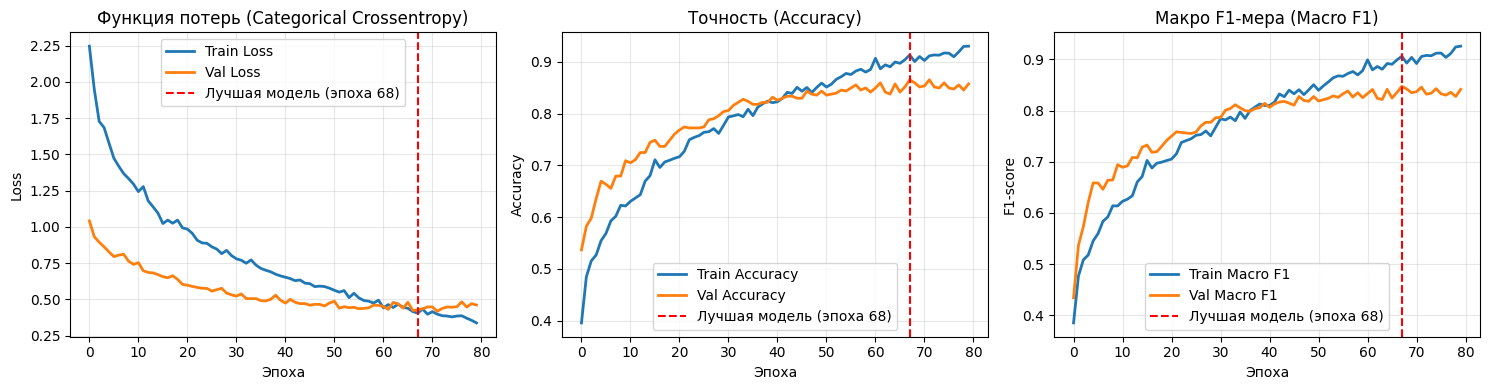

In [87]:
# Код для построения графиков обучения модели распознавания усталости
import matplotlib.pyplot as plt

def plot_training_history(history, best_epoch=None):
    """
    Визуализация истории обучения модели: потери, точность, F1-мера (macro)
    
    Аргументы:
    - history: история обучения
    - best_epoch: номер эпохи с лучшей моделью (будет отмечена вертикальной линией)
    """
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    # 1. Потери
    axes[0].plot(history.history['loss'], label='Train Loss', linewidth=2)
    axes[0].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
    if best_epoch:
        axes[0].axvline(x=best_epoch - 1, color='red', linestyle='--', 
                        label=f'Лучшая модель (эпоха {best_epoch})', linewidth=1.5)
    axes[0].set_title('Функция потерь (Categorical Crossentropy)')
    axes[0].set_xlabel('Эпоха')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # 2. Точность
    axes[1].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
    axes[1].plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
    if best_epoch:
        axes[1].axvline(x=best_epoch - 1, color='red', linestyle='--', 
                        label=f'Лучшая модель (эпоха {best_epoch})', linewidth=1.5)
    axes[1].set_title('Точность (Accuracy)')
    axes[1].set_xlabel('Эпоха')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    # 3. Macro F1-мера
    axes[2].plot(history.history['macro_f1'], label='Train Macro F1', linewidth=2)
    axes[2].plot(history.history['val_macro_f1'], label='Val Macro F1', linewidth=2)
    if best_epoch:
        axes[2].axvline(x=best_epoch - 1, color='red', linestyle='--', 
                        label=f'Лучшая модель (эпоха {best_epoch})', linewidth=1.5)
    axes[2].set_title('Макро F1-мера (Macro F1)')
    axes[2].set_xlabel('Эпоха')
    axes[2].set_ylabel('F1-score')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('training_history_fatigue.png', dpi=150)
    plt.show()

# Из лога обучения: лучшая модель сохранена на эпохе 68 (val_macro_f1 = 0.8556)
plot_training_history(history, best_epoch=68)

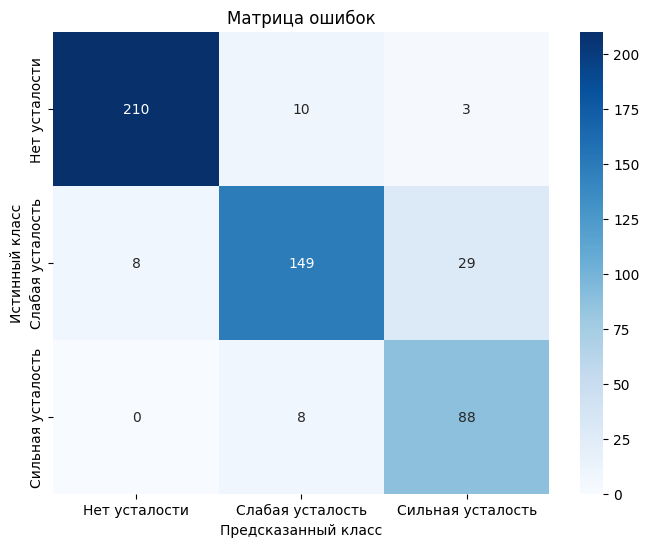

In [3]:
cm = np.array([[210,  10, 3], [8, 149, 29], [0, 8, 88]])
class_names = ['Нет усталости', 'Слабая усталость', 'Сильная усталость']

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.title('Матрица ошибок')
plt.show()